# **Support Vector Machine from Scratch**

## 0.ライブラリのインポートとデータの生成

ヒンジ損失の計算で符号の一致によって正誤を判定するため、SVMのラベルは(0, 1)ではなく(-1, 1)を使う。

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

X, y = make_blobs(n_samples=125, centers=2, cluster_std=2.8, random_state=42)
y = np.where(y == 0, -1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 1.アルゴリズム

マージンを最大化する決定境界を求めるアルゴリズム。ヒンジ損失を誤差関数として勾配降下法で最適化する。

### 1.1.マージンの最大化

マージンとは決定境界から最も近いデータ点までの距離のことであり、SVMでは2クラスのデータを分離する決定境界のうち、マージンが最大となるものを求める。  
決定境界からサポートベクターまでの距離は以下で表される。  
$$\text{margin} = \frac{2}{||w||}$$

### 1.2.ヒンジ損失

マージンの最大化と誤分類へのペナルティを同時に最適化する損失関数としてヒンジ損失を使う。  
$$L = \frac{1}{2}||w||^2 + C\sum_{i=1}^{n}\max(0, 1 - y_i(w \cdot x_i + b))$$

Lの値が小さければ小さいほど、マージンは大きくなる。

### 1.3.勾配降下法

ヒンジ損失をwとbで偏微分して勾配を求め、パラメータを更新する。  
・マージンの外のとき  
w = w - alpha * w  
・マージンの内側や誤分類のとき  
w = w - alpha * (w - C・y・x)  
b = b + alpha * C・y

In [72]:
def fit(X, y, alpha=0.0001, C=5.0, epochs=3000):
  w = np.zeros(X.shape[1])
  b = 0

  for epoch in range(epochs):
    for xi, yi in zip(X, y):
      if yi*(np.dot(w, xi) + b) >= 1:
        w = w - alpha*w
      else:
        w = w - alpha*(w - (C*yi*xi))
        b = b + alpha*C*yi

  return w, b

def predict(X, w, b):
    return np.sign(np.dot(X, w) + b).astype(int)

w, b = fit(X_train, y_train)

## 2.モデルの可視化

勾配降下法による近似解のため、厳密なサポートベクトルではなくマージン付近の点をサポートベクトルとして可視化している。

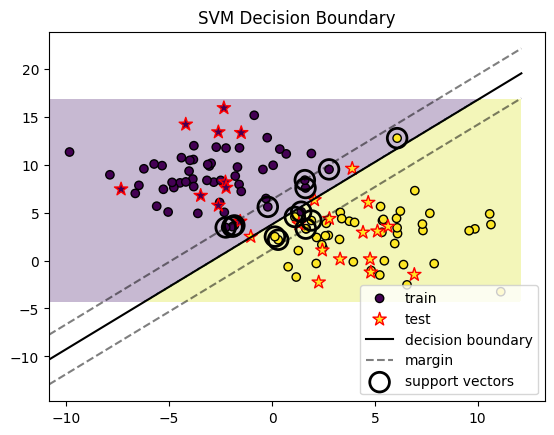

In [73]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = predict(grid, w, b)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k', label='train')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='r', marker='*', s=100, label='test')

x_line = np.linspace(x_min, x_max, 100)
y_line = -(w[0] * x_line + b) / w[1]
y_margin_pos = -(w[0] * x_line + b - 1) / w[1]
y_margin_neg = -(w[0] * x_line + b + 1) / w[1]

plt.plot(x_line, y_line, 'k-', label='decision boundary')
plt.plot(x_line, y_margin_pos, 'k--', alpha=0.5, label='margin')
plt.plot(x_line, y_margin_neg, 'k--', alpha=0.5)

margins = y_train * (np.dot(X_train, w) + b)
support_vectors = X_train[margins <= 1.01]
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=200, facecolors='none', edgecolors='k', linewidths=2, label='support vectors')

plt.title("SVM Decision Boundary")
plt.legend()
plt.show()

## 3.検証

### 3.1.精度

In [74]:
y_pred = predict(X_test, w, b)
accuracy = np.sum(y_pred == y_test) / len(y_test)
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.920


### 3.2.C比較

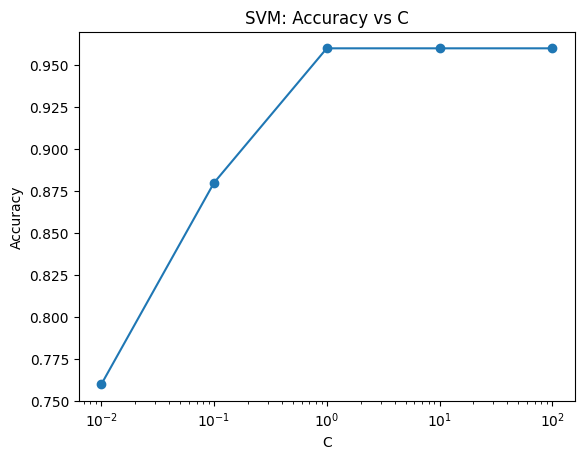

In [ ]:
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]
accuracies = []
for C in C_values:
  w_tmp, b_tmp = fit(X_train, y_train, alpha=0.0001, C=C, epochs=3000)
  y_tmp_pred = predict(X_test, w_tmp, b_tmp)
  acc = np.sum(y_tmp_pred == y_test) / len(y_test)
  accuracies.append(acc)

plt.plot(C_values, accuracies, marker='o')
plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("SVM: Accuracy vs C")
plt.show()